# Confronto Auto Elettriche vs Ibride in Italia (2015-2023)

Analisi della distribuzione di autovetture elettriche e ibride per 1.000 autovetture nei comuni capoluogo italiani.

## 1. Importazione librerie e caricamento dati

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configurazione per grafici ad alta risoluzione
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

In [6]:
# Caricamento dei dati
# NOTA: index_col=False è necessario per leggere correttamente questi CSV ISTAT
df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
                             encoding='utf-8-sig',
                             index_col=False)

df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',
                        encoding='utf-8-sig',
                        index_col=False)

print("✓ Dati caricati correttamente")
print(f"  - Elettriche: {df_elettriche.shape[0]} righe")
print(f"  - Ibride: {df_ibride.shape[0]} righe")

✓ Dati caricati correttamente
  - Elettriche: 1080 righe
  - Ibride: 1080 righe


## 2. Esplorazione dati

In [7]:
# Visualizzo le prime righe per capire la struttura
print("Struttura dati ELETTRICHE:")
print(df_elettriche[['FREQ', 'REF_AREA', 'Territorio', 'TIME_PERIOD', 'Osservazione']].head())
print(f"\nColonne disponibili: {list(df_elettriche.columns)}")

Struttura dati ELETTRICHE:
  FREQ REF_AREA Territorio  TIME_PERIOD Osservazione
0    A       IT     Italia         2015          0.2
1    A       IT     Italia         2016          0.2
2    A       IT     Italia         2017          0.3
3    A       IT     Italia         2018          0.4
4    A       IT     Italia         2019          0.8

Colonne disponibili: ['FREQ', 'Frequenza', 'REF_AREA', 'Territorio', 'DATA_TYPE', 'Indicatore', 'TIME_PERIOD', 'Osservazione', 'OBS_STATUS', '\'Stato dell"\'osservazione\'', 'NOTE_REF_AREA', 'Territorio (NOTE_REF_AREA)', 'NOTE_DATA_TYPE', 'Indicatore (NOTE_DATA_TYPE)', 'NOTE_TIME_PERIOD', 'Tempo (NOTE_TIME_PERIOD)', 'BASE_PER', 'Anno base', 'UNIT_MEAS', 'Unità di misura', 'UNIT_MULT', 'Unità di moltiplicazione']


In [8]:
print("Struttura dati IBRIDE:")
print(df_ibride[['FREQ', 'REF_AREA', 'Territorio', 'TIME_PERIOD', 'Osservazione']].head())

Struttura dati IBRIDE:
  FREQ REF_AREA Territorio  TIME_PERIOD  Osservazione
0    A       IT     Italia         2015           3.8
1    A       IT     Italia         2016           5.3
2    A       IT     Italia         2017           6.9
3    A       IT     Italia         2018           9.2
4    A       IT     Italia         2019          12.4


In [9]:
# Verifico i territori disponibili
print("Territori unici (primi 10):")
print(df_elettriche['Territorio'].unique()[:10])

Territori unici (primi 10):
['Italia' 'Nord' 'Nord-ovest' 'Torino' 'Vercelli' 'Novara' 'Cuneo' 'Asti'
 'Alessandria' 'Biella']


## 3. Preparazione dati per l'Italia

In [10]:
# Filtro solo i dati nazionali (REF_AREA == 'IT' corrisponde a Italia)
df_elettriche_it = df_elettriche[df_elettriche['REF_AREA'] == 'IT'].copy()
df_ibride_it = df_ibride[df_ibride['REF_AREA'] == 'IT'].copy()

print(f"Dati Italia - Elettriche: {len(df_elettriche_it)} anni")
print(f"Dati Italia - Ibride: {len(df_ibride_it)} anni")

Dati Italia - Elettriche: 9 anni
Dati Italia - Ibride: 9 anni


In [11]:
# Seleziono e rinomino le colonne necessarie
df_elettriche_it = df_elettriche_it[['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Elettriche'}
)

df_ibride_it = df_ibride_it[['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Ibride'}
)

In [12]:
# Merge dei due dataset
df_merged = pd.merge(df_elettriche_it, df_ibride_it, on='Anno')

# Conversione a numerico
df_merged['Elettriche'] = pd.to_numeric(df_merged['Elettriche'], errors='coerce')
df_merged['Ibride'] = pd.to_numeric(df_merged['Ibride'], errors='coerce')

# Rimuovo eventuali valori mancanti
df_merged = df_merged.dropna()

print("Dataset unificato:")
print(df_merged)

Dataset unificato:
   Anno  Elettriche  Ibride
0  2015         0.2     3.8
1  2016         0.2     5.3
2  2017         0.3     6.9
3  2018         0.4     9.2
4  2019         0.8    12.4
5  2020         1.7    19.6
6  2021         3.5    34.4
7  2022         4.6    49.6
8  2023         6.4    68.6


## 4. Analisi descrittiva

In [13]:
# Calcolo statistiche base
df_merged['Totale'] = df_merged['Elettriche'] + df_merged['Ibride']
df_merged['Perc_Elettriche'] = (df_merged['Elettriche'] / df_merged['Totale'] * 100).round(1)
df_merged['Perc_Ibride'] = (df_merged['Ibride'] / df_merged['Totale'] * 100).round(1)

print("Tabella riassuntiva completa:")
print(df_merged.to_string(index=False))

Tabella riassuntiva completa:
 Anno  Elettriche  Ibride  Totale  Perc_Elettriche  Perc_Ibride
 2015         0.2     3.8     4.0              5.0         95.0
 2016         0.2     5.3     5.5              3.6         96.4
 2017         0.3     6.9     7.2              4.2         95.8
 2018         0.4     9.2     9.6              4.2         95.8
 2019         0.8    12.4    13.2              6.1         93.9
 2020         1.7    19.6    21.3              8.0         92.0
 2021         3.5    34.4    37.9              9.2         90.8
 2022         4.6    49.6    54.2              8.5         91.5
 2023         6.4    68.6    75.0              8.5         91.5


In [14]:
# Statistiche descrittive
print("\nStatistiche descrittive:")
print(df_merged[['Elettriche', 'Ibride', 'Totale']].describe())


Statistiche descrittive:
       Elettriche     Ibride     Totale
count    9.000000   9.000000   9.000000
mean     2.011111  23.311111  25.322222
std      2.286616  22.835030  25.115472
min      0.200000   3.800000   4.000000
25%      0.300000   6.900000   7.200000
50%      0.800000  12.400000  13.200000
75%      3.500000  34.400000  37.900000
max      6.400000  68.600000  75.000000


## 5. Visualizzazione: Grafici a Torta Anno per Anno

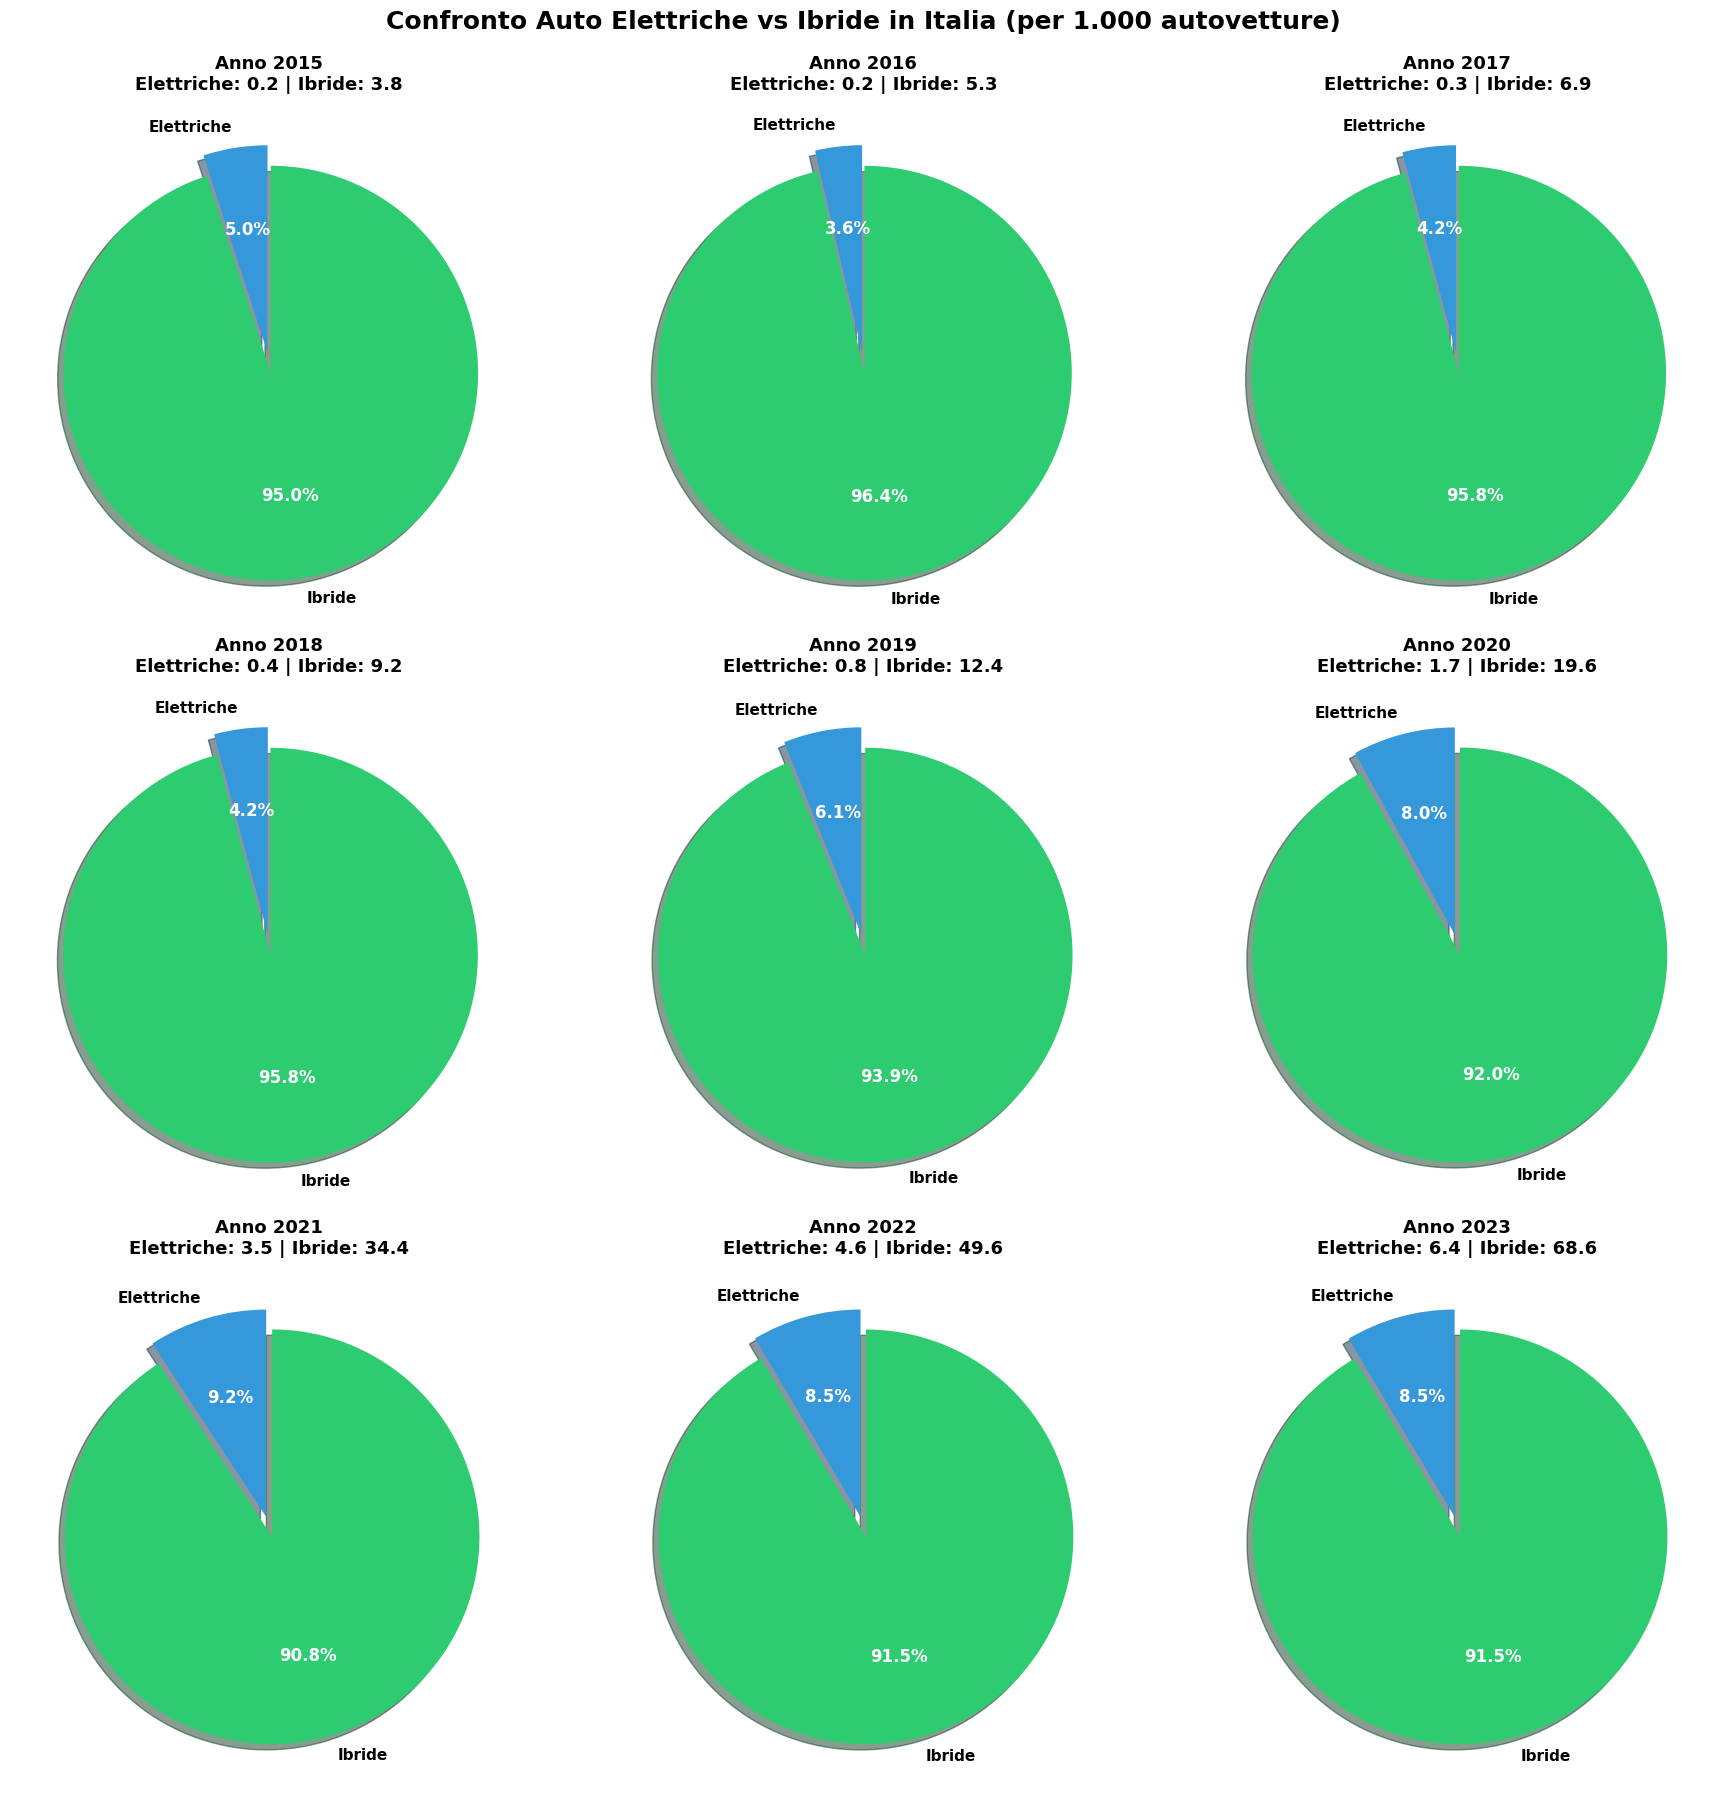

✓ Grafico a torta per anno salvato


In [15]:
# Preparo la griglia di grafici
anni = sorted(df_merged['Anno'].unique())
n_anni = len(anni)

# Calcolo righe e colonne per la griglia
n_cols = 3
n_rows = int(np.ceil(n_anni / n_cols))

# Creo la figura con tutti i grafici
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Confronto Auto Elettriche vs Ibride in Italia (per 1.000 autovetture)', 
             fontsize=18, fontweight='bold', y=0.995)

# Appiattisco l'array di axes per facilitare l'iterazione
if n_anni > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Colori personalizzati
colori = ['#3498db', '#2ecc71']  # Blu per elettriche, verde per ibride

# Creo un grafico per ogni anno
for idx, anno in enumerate(anni):
    dati_anno = df_merged[df_merged['Anno'] == anno].iloc[0]
    
    valori = [dati_anno['Elettriche'], dati_anno['Ibride']]
    etichette = ['Elettriche', 'Ibride']
    
    # Calcolo le percentuali
    totale = sum(valori)
    percentuali = [v/totale * 100 for v in valori]
    
    # Creo il grafico a torta
    wedges, texts, autotexts = axes[idx].pie(
        valori, 
        labels=etichette,
        autopct='%1.1f%%',
        startangle=90,
        colors=colori,
        explode=[0.05, 0.05],  # Leggera esplosione per entrambe le fette
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    # Miglioro la formattazione delle percentuali
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_fontweight('bold')
    
    # Titolo con anno e valori assoluti
    axes[idx].set_title(
        f'Anno {anno}\nElettriche: {valori[0]:.1f} | Ibride: {valori[1]:.1f}',
        fontsize=13,
        fontweight='bold',
        pad=10
    )

# Nascondo gli assi vuoti se ce ne sono
for idx in range(n_anni, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('confronto_elettriche_ibride_per_anno.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico a torta per anno salvato")

## 6. Visualizzazione: Evoluzione Temporale

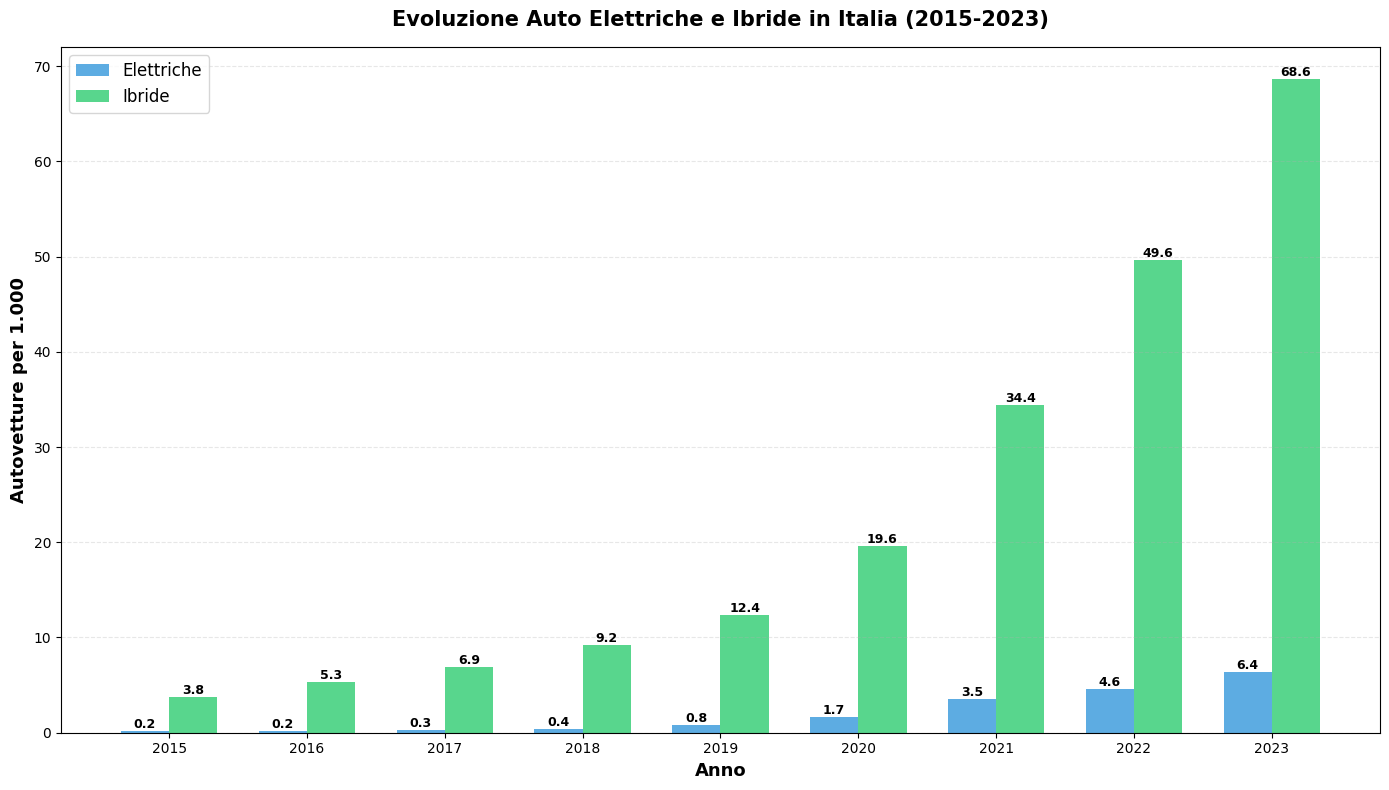

✓ Grafico evoluzione temporale salvato


In [16]:
# Grafico a barre per l'evoluzione temporale
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(anni))
width = 0.35

bars1 = ax.bar(x - width/2, df_merged['Elettriche'], width, 
                label='Elettriche', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, df_merged['Ibride'], width,
                label='Ibride', color='#2ecc71', alpha=0.8)

# Aggiungo i valori sopra le barre
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Anno', fontsize=13, fontweight='bold')
ax.set_ylabel('Autovetture per 1.000', fontsize=13, fontweight='bold')
ax.set_title('Evoluzione Auto Elettriche e Ibride in Italia (2015-2023)', 
              fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(anni)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('evoluzione_elettriche_ibride.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico evoluzione temporale salvato")

## 7. Analisi dei trend

In [17]:
# Calcolo tassi di crescita anno su anno
df_merged_sorted = df_merged.sort_values('Anno').reset_index(drop=True)

df_merged_sorted['Crescita_Elettriche_%'] = df_merged_sorted['Elettriche'].pct_change() * 100
df_merged_sorted['Crescita_Ibride_%'] = df_merged_sorted['Ibride'].pct_change() * 100

print("Tassi di crescita anno su anno:")
print(df_merged_sorted[['Anno', 'Crescita_Elettriche_%', 'Crescita_Ibride_%']].to_string(index=False))

Tassi di crescita anno su anno:
 Anno  Crescita_Elettriche_%  Crescita_Ibride_%
 2015                    NaN                NaN
 2016               0.000000          39.473684
 2017              50.000000          30.188679
 2018              33.333333          33.333333
 2019             100.000000          34.782609
 2020             112.500000          58.064516
 2021             105.882353          75.510204
 2022              31.428571          44.186047
 2023              39.130435          38.306452


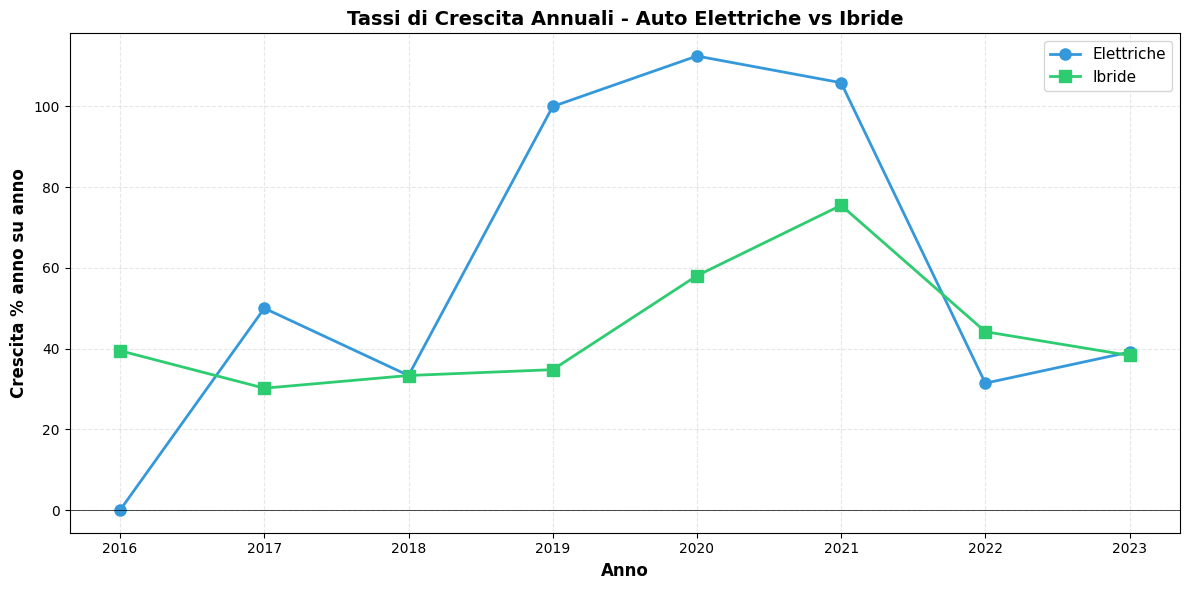

✓ Grafico crescita anno su anno salvato


In [18]:
# Grafico dei tassi di crescita
fig, ax = plt.subplots(figsize=(12, 6))

# Escludo il primo anno (NaN)
df_crescita = df_merged_sorted[1:]

ax.plot(df_crescita['Anno'], df_crescita['Crescita_Elettriche_%'], 
        marker='o', linewidth=2, markersize=8, label='Elettriche', color='#3498db')
ax.plot(df_crescita['Anno'], df_crescita['Crescita_Ibride_%'], 
        marker='s', linewidth=2, markersize=8, label='Ibride', color='#2ecc71')

ax.set_xlabel('Anno', fontsize=12, fontweight='bold')
ax.set_ylabel('Crescita % anno su anno', fontsize=12, fontweight='bold')
ax.set_title('Tassi di Crescita Annuali - Auto Elettriche vs Ibride', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('crescita_anno_su_anno.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico crescita anno su anno salvato")

## 8. Conclusioni

### Principali osservazioni:

1. **Dominanza delle ibride**: Le auto ibride rappresentano il 91-96% del mercato elettrificato italiano
2. **Crescita accelerata**: Entrambe le tipologie mostrano una forte accelerazione dal 2020 in poi
3. **Base di partenza**: Le elettriche partono da valori molto bassi (0.2 per 1000 nel 2015) ma crescono rapidamente
4. **Trend recente**: Dal 2020 al 2023, le auto ibride sono cresciute da 19.6 a 68.6 per 1000 (+250%)
5. **Elettriche in crescita**: Le auto elettriche sono passate da 1.7 a 6.4 per 1000 (+276%) nello stesso periodo